In [ ]:
Import Neccessary Libraries

In [20]:

import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

In [21]:
cars = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\cardekho_imputated.csv")
cars

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [23]:
cars['transmission_type'].nunique()

2

In [24]:
cars['seller_type'].nunique()

3

In [25]:
cars['fuel_type'].nunique()

5

In [26]:
from sklearn.preprocessing import OrdinalEncoder
columns_to_encode = ['transmission_type', 'fuel_type', 'seller_type']
encoder = OrdinalEncoder()
cars[columns_to_encode] = encoder.fit_transform(cars[columns_to_encode]).astype(int)
cars

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,1,4,1,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,1,4,1,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,0,1,1,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,0,4,1,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,0,4,1,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,0,1,1,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,0,1,1,16.00,2179,140.00,7,1225000


In [27]:
cars = cars.drop(columns=['car_name','brand','model'])
cars

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,9,120000,1,4,1,19.70,796,46.30,5,120000
1,1,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,2,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,3,9,37000,1,4,1,20.92,998,67.10,5,226000
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,0,4,1,19.81,1086,68.05,5,250000
15407,19540,2,18000,0,4,1,17.50,1373,91.10,7,925000
15408,19541,6,67000,0,1,1,21.14,1498,103.52,5,425000
15409,19542,5,3800000,0,1,1,16.00,2179,140.00,7,1225000


In [28]:
from sklearn.preprocessing import OrdinalEncoder
columns_to_encode = ['transmission_type', 'fuel_type', 'seller_type']
encoder = OrdinalEncoder()
cars[columns_to_encode] = encoder.fit_transform(cars[columns_to_encode]).astype(int)
cars

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,9,120000,1,4,1,19.70,796,46.30,5,120000
1,1,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,2,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,3,9,37000,1,4,1,20.92,998,67.10,5,226000
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,0,4,1,19.81,1086,68.05,5,250000
15407,19540,2,18000,0,4,1,17.50,1373,91.10,7,925000
15408,19541,6,67000,0,1,1,21.14,1498,103.52,5,425000
15409,19542,5,3800000,0,1,1,16.00,2179,140.00,7,1225000


In [29]:
x = cars.drop(['selling_price'],axis = 1)
x

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,9,120000,1,4,1,19.70,796,46.30,5
1,1,5,20000,1,4,1,18.90,1197,82.00,5
2,2,11,60000,1,4,1,17.00,1197,80.00,5
3,3,9,37000,1,4,1,20.92,998,67.10,5
4,4,6,30000,0,1,1,22.77,1498,98.59,5
...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,0,4,1,19.81,1086,68.05,5
15407,19540,2,18000,0,4,1,17.50,1373,91.10,7
15408,19541,6,67000,0,1,1,21.14,1498,103.52,5
15409,19542,5,3800000,0,1,1,16.00,2179,140.00,7


In [30]:
y = cars['selling_price']
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64

In [31]:
x.head()

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,9,120000,1,4,1,19.70,796,46.30,5
1,1,5,20000,1,4,1,18.90,1197,82.00,5
2,2,11,60000,1,4,1,17.00,1197,80.00,5
3,3,9,37000,1,4,1,20.92,998,67.10,5
4,4,6,30000,0,1,1,22.77,1498,98.59,5


In [32]:
y.head()

0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64

In [33]:
cars.shape

(15411, 11)

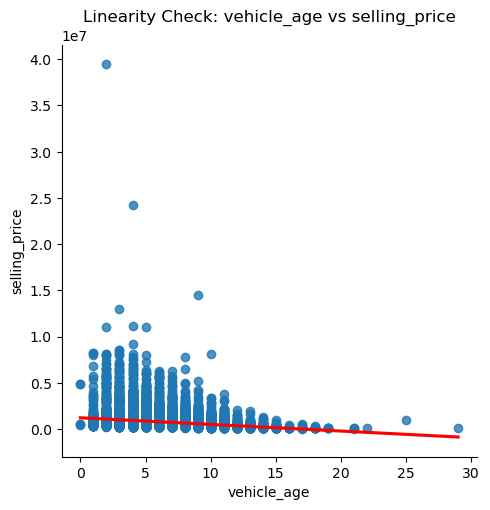

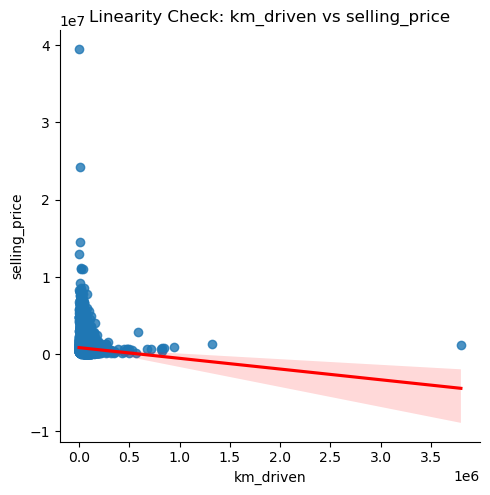

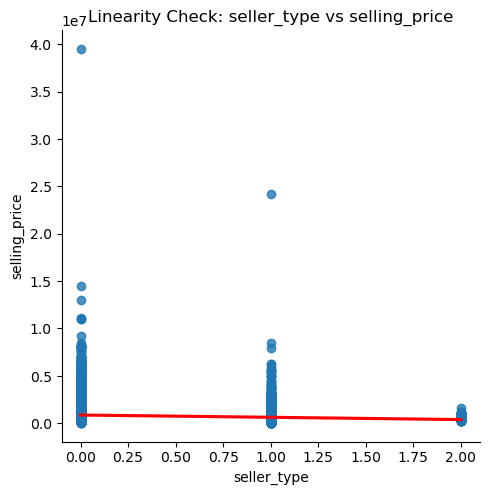

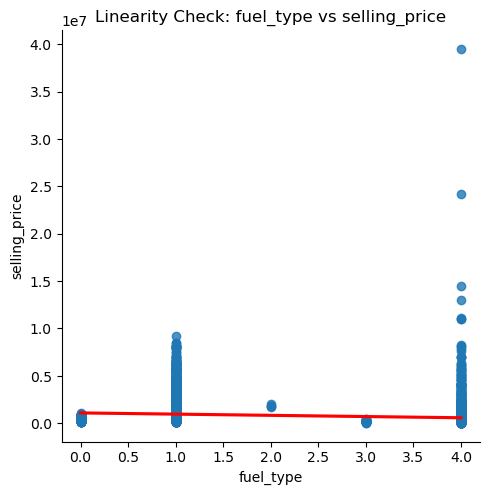

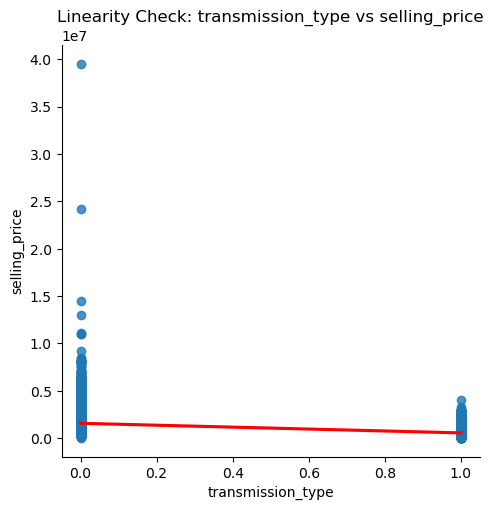

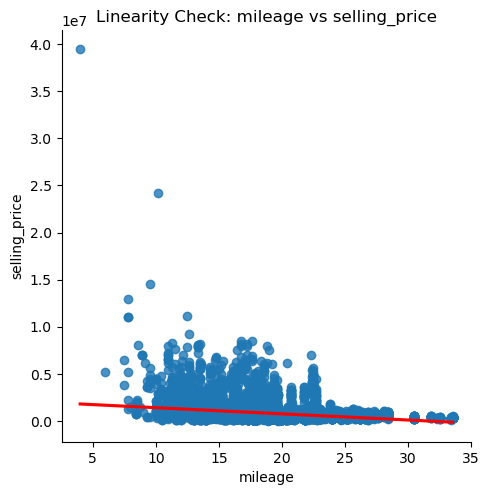

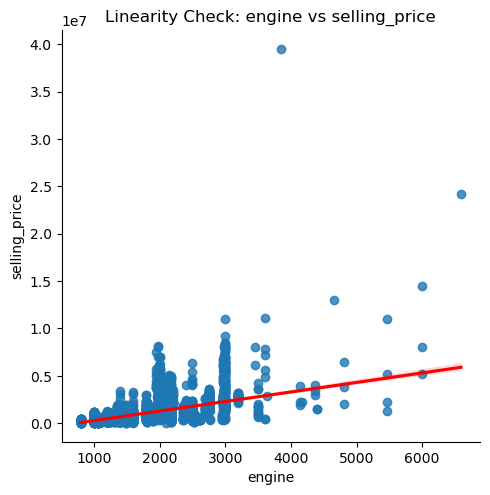

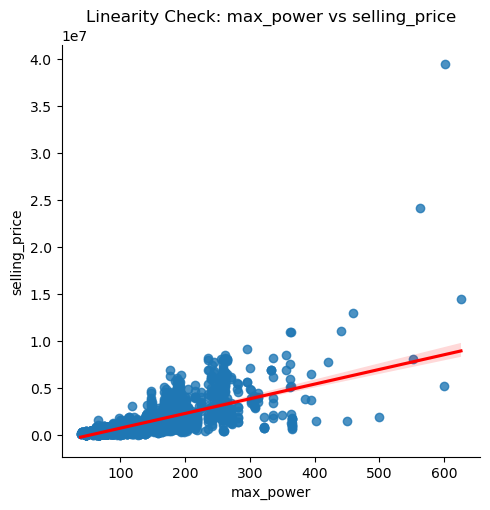

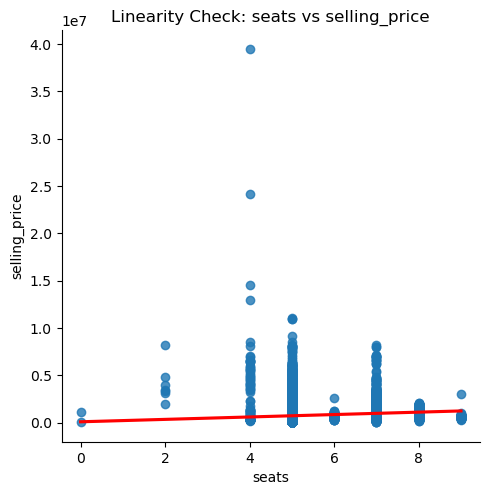

In [35]:
features = ['vehicle_age','km_driven','seller_type','fuel_type','transmission_type','mileage','engine','max_power','seats']
target = 'selling_price'
for col in features:
    sns.lmplot(x=col, y=target, data=cars, line_kws={'color': 'red'})
    plt.title(f"Linearity Check: {col} vs {target}")
    plt.show()

In [36]:
cars.corr()

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
Unnamed: 0,1.000000,-0.006250,-0.003778,-0.057218,0.011664,-0.040184,-0.014699,0.012972,0.039367,-0.031832,0.030523
vehicle_age,-0.006250,1.000000,0.333891,-0.056234,-0.007613,0.080711,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,-0.003778,0.333891,1.000000,0.036078,-0.245421,0.073501,-0.105239,0.192885,0.044421,0.192830,-0.080030
seller_type,-0.057218,-0.056234,0.036078,1.000000,0.046451,0.197564,0.082295,-0.120694,-0.184449,0.039560,-0.137198
fuel_type,0.011664,-0.007613,-0.245421,0.046451,1.000000,0.005156,-0.155834,-0.447268,-0.258257,-0.329337,-0.217803
transmission_type,-0.040184,0.080711,0.073501,0.197564,0.005156,1.000000,0.282738,-0.348607,-0.539448,0.058527,-0.459394
mileage,-0.014699,-0.257394,-0.105239,0.082295,-0.155834,0.282738,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.012972,0.098965,0.192885,-0.120694,-0.447268,-0.348607,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.039367,0.005208,0.044421,-0.184449,-0.258257,-0.539448,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,-0.031832,0.030791,0.192830,0.039560,-0.329337,0.058527,-0.440280,0.551236,0.172257,1.000000,0.115033


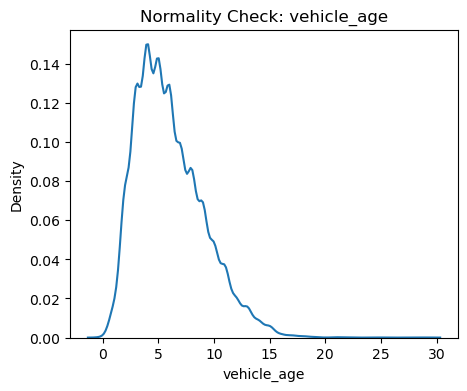

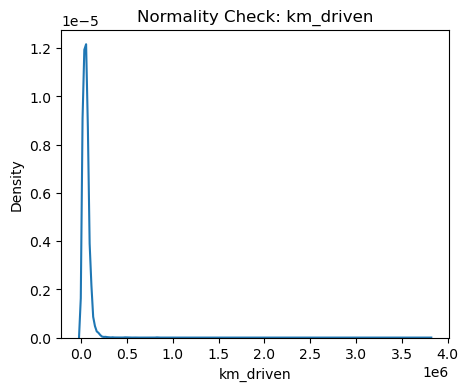

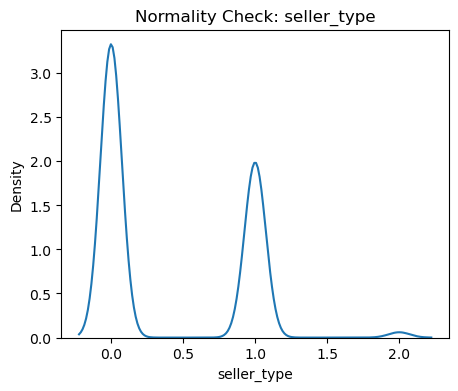

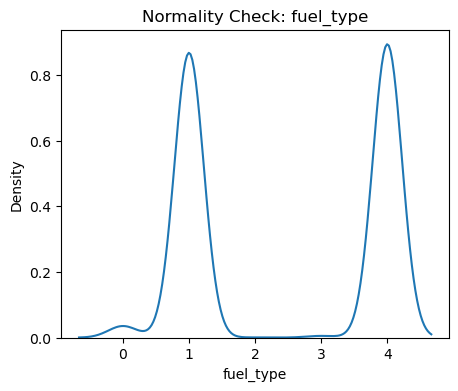

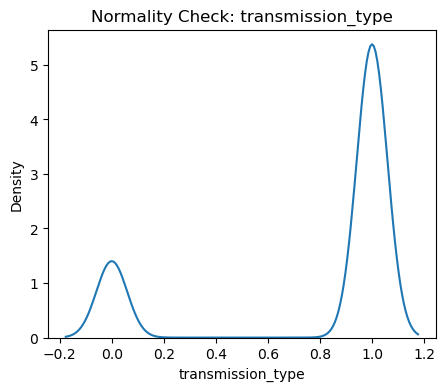

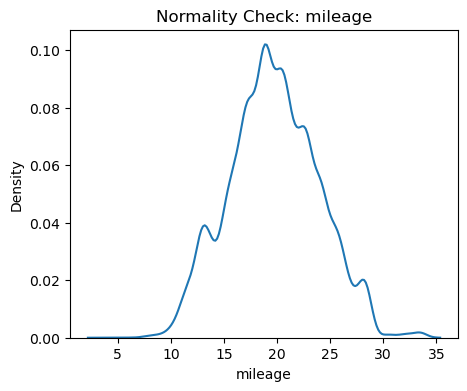

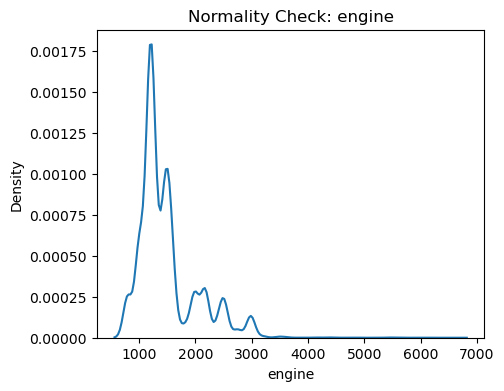

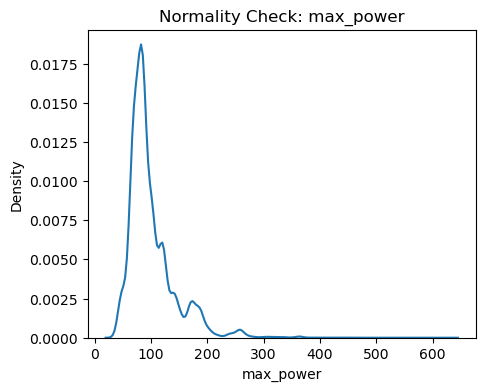

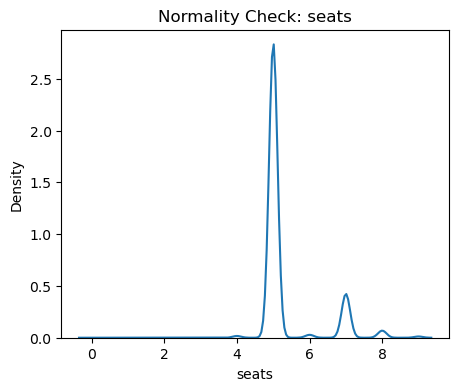

In [37]:
for col in features:
    plt.figure(figsize=(5, 4))
    sns.distplot(cars[col],hist=False)
    plt.title(f"Normality Check: {col}")
    plt.show()

In [15]:
### Train Test Split
from sklearn.model_selection import train_test_split

In [17]:
#model validation or data validation
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [18]:
print(x_train,x_test,y_train,y_test)

       Unnamed: 0  vehicle_age  km_driven  seller_type  fuel_type  \
11210       14238            7      70252            0          1   
1347         1731            2      10000            1          4   
10363       13218            2       6000            0          1   
316           403            7      63000            0          4   
10638       13550           10      80292            0          4   
...           ...          ...        ...          ...        ...   
5191         6581            7     127731            0          1   
13418       17029           11      59000            0          4   
5390         6839            7      20000            1          4   
860          1104            2      15000            0          4   
7270         9295            2      30000            1          4   

       transmission_type  mileage  engine  max_power  seats  
11210                  0    11.20    2400     215.00      5  
1347                   1    23.84    1199      

In [19]:

from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)

LinearRegression()

In [21]:

y_pred=regression.predict(x_test)

In [22]:

from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.6637887915599728


In [24]:
regression.predict([[1200,
    5,
    45000,
    1,
    4,
    0,
    19.5,
    1197,
    82.0,
    5]])

array([620149.58243816])

In [25]:
### Create a Pickle file using serialization 
import pickle
pickle_out = open("mlr.pkl","wb")
pickle.dump(regression, pickle_out)
pickle_out.close()

In [26]:
import numpy as np

In [27]:
!pip install streamlit

In [28]:
!pip install --upgrade streamlit